# Phase 1: Disruption Detection

This notebook builds and checks the disruption detection layer for the
supply chain risk intelligence project: flagging demand shocks that
aren't explained by known promotions or holidays, and detecting
change points where a store/category's underlying demand pattern shifts.

It reuses the cleaned daily sales panel from the
[retail-demand-forecasting](https://github.com/MIthila-Samapti/retail-demand-forecasting)
project rather than starting from raw data again.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src.disruption_detection import (
    load_panel, add_seasonal_baseline, compute_residuals,
    flag_shocks, detect_changepoints, summarize_disruption_risk,
)

pd.set_option('display.max_columns', None)

## Load the panel and build the seasonal baseline

The baseline is a trailing median of unit sales for the same
store/family/day-of-week, over the last 8 occurrences. It updates week by
week rather than being fixed at one forecast cutoff, since here we care
about ongoing monitoring, not a single forecast horizon.

In [2]:
panel = load_panel('../data/processed/daily_sales_by_store_family.csv')
panel = add_seasonal_baseline(panel, window_weeks=8)
panel = compute_residuals(panel)

print(panel.shape, panel.store_nbr.nunique(), 'stores x', panel.family.nunique(), 'families')
panel[['date','store_nbr','family','unit_sales','expected_sales','residual']].head()

(133096, 14) 10 stores x 8 families


,date,store_nbr,family,unit_sales,expected_sales,residual
0,2013-01-02,3,BEVERAGES,4486.0,NaN,NaN
1,2013-01-03,3,BEVERAGES,3367.0,NaN,NaN
2,2013-01-04,3,BEVERAGES,3283.0,NaN,NaN
3,2013-01-05,3,BEVERAGES,4886.0,NaN,NaN
4,2013-01-06,3,BEVERAGES,5474.0,NaN,NaN


## Flag unexplained demand shocks

A day is flagged as a disruption shock if its residual is more than 3
rolling standard deviations from zero, **and** there's no known
promotion or holiday to explain it. Shocks that coincide with a known
driver aren't disruptions — they already have an explanation.

In [3]:
shocks = flag_shocks(panel, z_window=90, z_thresh=3.0, min_periods=20)

n_shocks = shocks['is_disruption_shock'].sum()
print(f'{n_shocks} unexplained shocks flagged out of {len(shocks):,} store/category/day observations '
      f'({n_shocks / len(shocks):.2%})')

912 unexplained shocks flagged out of 133,096 store/category/day observations (0.69%)


## Change-point detection

The z-score check catches single-day spikes. It won't catch a sustained
shift in demand level that happens gradually or all at once but stays
there. For that, PELT change-point detection runs on each store/family's
residual series.

The penalty is scaled to each series' own variance (`penalty_mult * log(n)
* variance`, a standard BIC-style formula) rather than one fixed
threshold, because different categories operate at very different sales
volumes — a fixed threshold would be far too sensitive for a
high-volume category and not sensitive enough for a low-volume one.

In [4]:
changepoints = detect_changepoints(panel, penalty_mult=5.0, min_size=21, min_obs=60)
print(f'{len(changepoints)} change points detected across {panel.groupby(["store_nbr","family"]).ngroups} series')
changepoints.groupby(['store_nbr','family']).size().sort_values(ascending=False).head(10)

332 change points detected across 80 series


store_nbr  family   
3          PRODUCE      13
44         PRODUCE      13
45         PRODUCE      13
49         PRODUCE      13
47         PRODUCE      13
51         PRODUCE      13
50         PRODUCE      13
46         PRODUCE      13
8          BEVERAGES    12
45         BEVERAGES    12
dtype: int64

## A real structural break the detector caught

The change points aren't evenly spread across categories — PRODUCE
accounts for most of the top hits. Looking at one example (Store 51,
PRODUCE) shows why: unit sales jump from roughly 10-50 units/day to
roughly 4,000-8,000 units/day almost overnight on **January 2, 2014**,
and the same jump shows up across nearly every store for this category
around the same date.

In [5]:
example = panel[(panel.store_nbr == 51) & (panel.family == 'PRODUCE')].sort_values('date')
example[(example.date >= '2013-12-20') & (example.date <= '2014-01-15')][['date', 'unit_sales']]

,date,unit_sales
131773,2013-12-20,35.0000
131774,2013-12-21,29.0000
131775,2013-12-22,20.0000
131776,2013-12-23,19.0000
131777,2013-12-24,10.0000
131778,2013-12-26,16.0000
131779,2013-12-27,49.0000
131780,2013-12-28,8.0000
131781,2013-12-29,13.0000
131782,2013-12-30,9.0000


That's not noise — it's a real, large, consistent discontinuity in the
raw data. The most likely explanation is that the store network
significantly expanded its tracked produce assortment in early January
2014 (going from a handful of produce items per store to a full
assortment), rather than an actual ~250x jump in customer demand
overnight. I can't confirm the operational cause from this dataset alone,
but that's exactly the point of this layer: it flags the shift and hands
an analyst a specific date and category to go verify, instead of quietly
absorbing it into a forecast or an averaged trend line.

It also means a risk score built on all-time history would be dominated
by this one early-2014 assortment change rather than by current risk.
That's why the risk summary below only looks at the most recent 90 days
of data, not the full history.

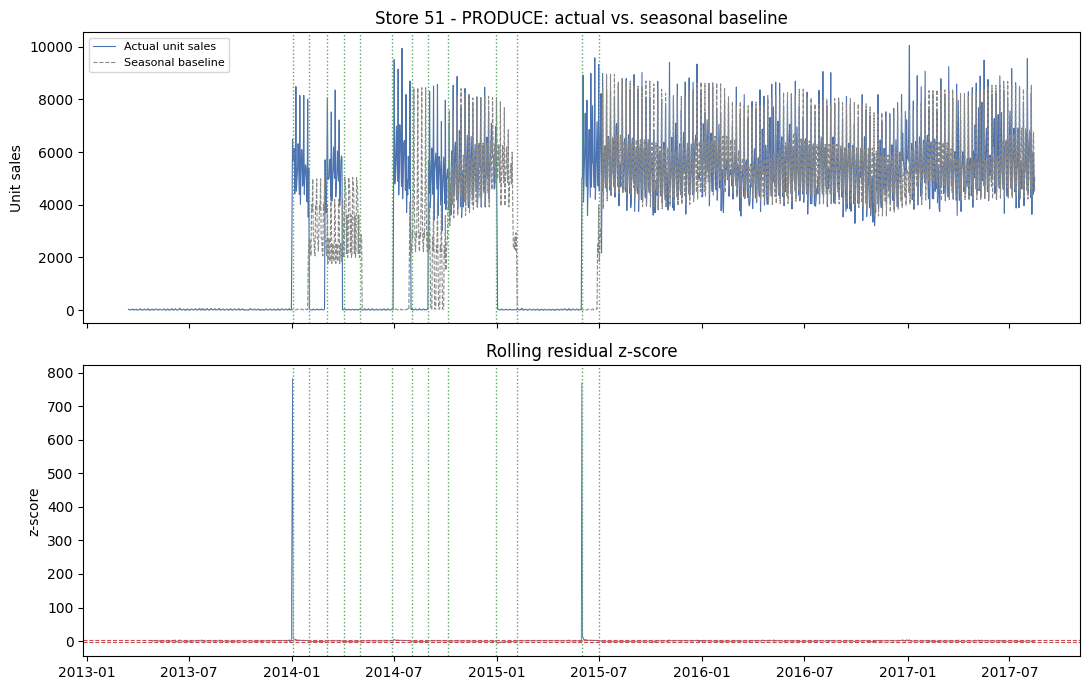

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ex_cps = changepoints[(changepoints.store_nbr == 51) & (changepoints.family == 'PRODUCE')]

axes[0].plot(example['date'], example['unit_sales'], color='#4C72B0', linewidth=0.8, label='Actual unit sales')
axes[0].plot(example['date'], example['expected_sales'], color='#888888', linewidth=0.8, linestyle='--', label='Seasonal baseline')
axes[0].set_title('Store 51 - PRODUCE: actual vs. seasonal baseline')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_ylabel('Unit sales')

axes[1].plot(shocks[(shocks.store_nbr == 51) & (shocks.family == 'PRODUCE')]['date'],
             shocks[(shocks.store_nbr == 51) & (shocks.family == 'PRODUCE')]['residual_z'],
             color='#4C72B0', linewidth=0.6)
axes[1].axhline(3, color='#C44E52', linestyle='--', linewidth=0.8)
axes[1].axhline(-3, color='#C44E52', linestyle='--', linewidth=0.8)
axes[1].set_title('Rolling residual z-score')
axes[1].set_ylabel('z-score')

for d in ex_cps['date']:
    for ax in axes:
        ax.axvline(pd.Timestamp(d), color='#55A868', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

## Composite disruption risk summary (most recent 90 days)

This is the feature table the next phase's composite risk score builds
on: shock count, average shock severity, and change-point count per
store/category, over the most recent 90 days only — so a category that
looks risky today isn't being masked or exaggerated by something that
happened years ago.

In [7]:
risk_summary = summarize_disruption_risk(shocks, changepoints, window_days=90)
risk_summary.sort_values('shock_count', ascending=False).head(10)

,store_nbr,family,shock_count,avg_abs_z,changepoint_count
62,49,POULTRY,1,0.696162,0.0
0,3,BEVERAGES,0,0.577830,0.0
2,3,CLEANING,0,0.734966,0.0
1,3,BREAD/BAKERY,0,0.570770,0.0
4,3,GROCERY I,0,0.601519,0.0
5,3,MEATS,0,0.690770,0.0
6,3,POULTRY,0,0.685023,0.0
3,3,DAIRY,0,0.624632,0.0
8,8,BEVERAGES,0,0.585410,0.0
9,8,BREAD/BAKERY,0,0.682474,0.0


## Saving outputs

These feed directly into the Phase 2 composite risk score and the
Tableau/Power BI exports.

In [8]:
shocks[['date','store_nbr','family','unit_sales','expected_sales','residual','residual_z',
         'n_items_on_promo','is_holiday','is_disruption_shock']].to_csv('../reports/disruption_shocks.csv', index=False)
changepoints.to_csv('../reports/changepoints.csv', index=False)
risk_summary.to_csv('../reports/risk_summary.csv', index=False)
print('saved')

saved
